# MLP Learning in PyTorch: Introduction to Deep Learning with MNIST

**Course:** Introduction to Deep Learning  
**Topic:** Basic Neural Networks with Multilayer Perceptrons  
**Format:** Guided lab notebook

In this lab, you will build, train, evaluate, and improve a simple Multilayer Perceptron (MLP) for handwritten digit classification using the MNIST dataset.

# Learning Objectives

By the end of this lab, you should be able to:

- explain what a Multilayer Perceptron (MLP) is
- preprocess image data for a dense neural network
- build and train a simple MLP in PyTorch
- evaluate a classifier beyond overall accuracy
- identify signs of underfitting and overfitting
- improve a baseline model through experimentation

# Quick Reminder: What is an MLP?

A **Multilayer Perceptron (MLP)** is a feedforward neural network made of:

- an **input layer**
- one or more **hidden layers**
- an **output layer**

Each neuron computes a weighted sum of its inputs, adds a bias, then applies an activation function.

For image classification with MNIST:

- **input** = pixel values
- **output** = one of 10 digit classes (0 to 9)

> Important: MLPs work with vectors, so images must be flattened before being fed into the network.

# Before Coding

Answer these questions before running the notebook:

1. Why can an MLP not directly process a `28 x 28` image without reshaping it?
2. Why do we normalize pixel values?
3. Why do we use one-hot encoding for the labels? *(Note: in PyTorch, `CrossEntropyLoss` expects plain integer labels, not one-hot vectors — we'll revisit this below.)*
4. Why is `softmax` a good choice for the output layer in a multiclass classification problem?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
Using device: cuda


# Step 1 — Import the Required Libraries

We use:

- **NumPy** for array manipulation
- **Matplotlib** for visualization
- **PyTorch** (`torch`, `torch.nn`, `torch.optim`) for building and training the neural network
- **torchvision** to download and load the MNIST dataset
- **scikit-learn** for evaluation metrics

In [2]:
np.random.seed(42)
torch.manual_seed(42)

print("Random seeds set.")

Random seeds set.


# Why Set a Random Seed?

Setting a seed improves reproducibility and helps us obtain similar results across runs.

**Question:**  
Why might two trainings of the same model still produce slightly different results?

> Note: on GPU, some CUDA operations are non-deterministic by default even with a fixed seed. For stricter reproducibility you can additionally set `torch.backends.cudnn.deterministic = True`.

In [3]:
train_dataset_raw = datasets.MNIST(root="./data", train=True, download=True)
test_dataset_raw = datasets.MNIST(root="./data", train=False, download=True)

X_train = train_dataset_raw.data.numpy()
y_train = train_dataset_raw.targets.numpy()
X_test = test_dataset_raw.data.numpy()
y_test = test_dataset_raw.targets.numpy()

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.93MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.37MB/s]


# Step 2 — Load the MNIST Dataset

MNIST contains grayscale images of handwritten digits:

- training set: 60,000 images
- test set: 10,000 images
- image size: `28 x 28`
- classes: digits from 0 to 9

In [4]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Min pixel value: 0
Max pixel value: 255


# Inspecting the Data

**Questions:**

1. What is the shape of the training images?
2. What is the shape of the training labels?
3. What do the minimum and maximum pixel values tell us?
4. Are the images already in grayscale?

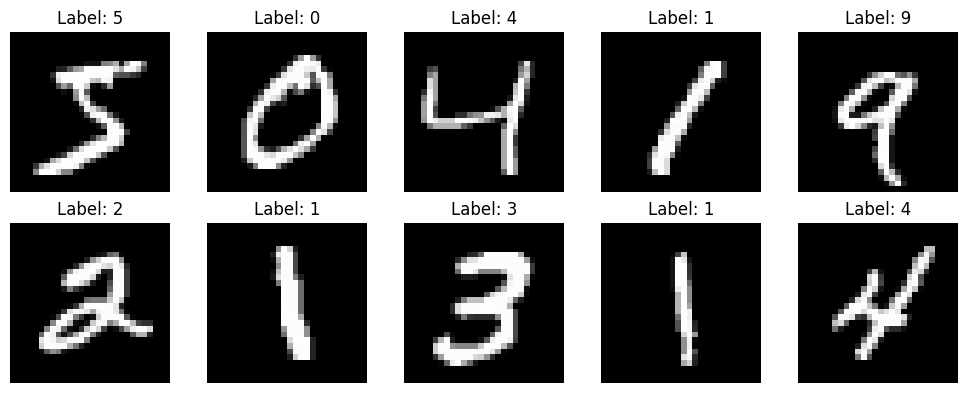

In [5]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Step 3 — Visualize Some Examples

This helps us understand what the model will learn from.

**Questions:**

1. Are all digits easy for a human to recognize?
2. Which digits seem visually ambiguous?
3. Why is visualization an important first step in a machine learning workflow?

In [6]:
X_train = X_train.reshape(X_train.shape[0], 28 * 28).astype("float32") / 255.0
X_test = X_test.reshape(X_test.shape[0], 28 * 28).astype("float32") / 255.0

In [7]:
print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)
print("New min value:", X_train.min())
print("New max value:", X_train.max())

New X_train shape: (60000, 784)
New X_test shape: (10000, 784)
New min value: 0.0
New max value: 1.0


# Step 4 — Preprocess the Input Data

We do two things:

- **flatten** each `28 x 28` image into a vector of size `784`
- **normalize** pixel values into the range `[0, 1]`

**Important note:**  
MNIST images are already grayscale.  
Here, we are **not** converting them to grayscale — we are reshaping and normalizing them.

**Questions:**

1. Why do we flatten the images for an MLP?
2. Why do we divide by 255?
3. What is the final number of input features for each image?

In [8]:
# In PyTorch, nn.CrossEntropyLoss combines log-softmax + negative log-likelihood
# and expects integer class labels directly (shape: [N]), NOT one-hot vectors.
# So instead of one-hot encoding, we simply convert labels to torch.long tensors.
y_train_labels = torch.tensor(y_train, dtype=torch.long)
y_test_labels = torch.tensor(y_test, dtype=torch.long)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

In [9]:
print("Original label:", y_train[0])
print("Tensor label (class index):", y_train_labels[0].item())
print("(Equivalent one-hot would be):", np.eye(10)[y_train[0]])

Original label: 5
Tensor label (class index): 5
(Equivalent one-hot would be): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# Step 5 — Encode the Target Labels

In Keras, labels are one-hot encoded (e.g. `7` → `[0,0,0,0,0,0,0,1,0,0]`) because `categorical_crossentropy` expects a probability vector as target.

In PyTorch, `nn.CrossEntropyLoss` expects **plain integer class indices** (e.g. `7`) and applies `log_softmax` internally. So no one-hot encoding is needed — we just keep labels as `long` tensors.

**Questions:**

1. What does the label `3` become after one-hot encoding (conceptually)?
2. Why is one-hot encoding useful for `categorical_crossentropy`, and why is it *not* needed for PyTorch's `CrossEntropyLoss`?
3. What would happen if we kept the labels as floats instead of integers/long tensors?

# Step 6 — Build a Baseline MLP

We start with a simple architecture:

- input: 784 features
- hidden layer 1: 350 neurons, ReLU
- hidden layer 2: 50 neurons, ReLU
- output layer: 10 neurons (raw logits — softmax is applied internally by the loss)

This model has **2 hidden layers**, not 3.

In [10]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden1=350, hidden2=50, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        # Note: no softmax here. nn.CrossEntropyLoss expects raw logits
        # and applies log_softmax internally for numerical stability.
        return self.net(x)

model = MLP().to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=350, bias=True)
    (1): ReLU()
    (2): Linear(in_features=350, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=10, bias=True)
  )
)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

for name, param in model.named_parameters():
    print(f"{name:20s} {str(list(param.shape)):15s} {param.numel():,} params")

# Understanding the Architecture

**Questions:**

1. How many hidden layers does the model have?
2. Which layer has the largest number of parameters?
3. Why does the output layer contain 10 neurons?
4. Why is `ReLU` used in the hidden layers?
5. Why is `softmax` applied inside the loss function instead of inside the model here?

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Step 7 — Define the Loss and Optimizer

We choose:

- **Adam** as optimizer
- **CrossEntropyLoss** as loss (combines `log_softmax` + negative log-likelihood, and takes raw logits + integer labels)
- **accuracy**, computed manually, as evaluation metric

**Questions:**

1. What is the role of the optimizer?
2. Why is `CrossEntropyLoss` appropriate here?
3. Why is accuracy useful, but not always sufficient?

In [12]:
# Split off 20% of the training data for validation, mirroring validation_split=0.2 in Keras
full_train_dataset = TensorDataset(X_train_t, y_train_labels)

val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

batch_size = 250
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {train_size}, Validation samples: {val_size}")

Training samples: 48000, Validation samples: 12000


In [13]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

    return history

In [14]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10)

Epoch 1/10 - loss: 0.5156 - accuracy: 0.8635 - val_loss: 0.2695 - val_accuracy: 0.9235
Epoch 2/10 - loss: 0.1991 - accuracy: 0.9432 - val_loss: 0.1873 - val_accuracy: 0.9473
Epoch 3/10 - loss: 0.1430 - accuracy: 0.9586 - val_loss: 0.1555 - val_accuracy: 0.9535
Epoch 4/10 - loss: 0.1080 - accuracy: 0.9684 - val_loss: 0.1260 - val_accuracy: 0.9626
Epoch 5/10 - loss: 0.0858 - accuracy: 0.9749 - val_loss: 0.1103 - val_accuracy: 0.9677
Epoch 6/10 - loss: 0.0673 - accuracy: 0.9803 - val_loss: 0.0985 - val_accuracy: 0.9696
Epoch 7/10 - loss: 0.0559 - accuracy: 0.9836 - val_loss: 0.0921 - val_accuracy: 0.9726
Epoch 8/10 - loss: 0.0438 - accuracy: 0.9876 - val_loss: 0.0964 - val_accuracy: 0.9721
Epoch 9/10 - loss: 0.0376 - accuracy: 0.9890 - val_loss: 0.0905 - val_accuracy: 0.9722
Epoch 10/10 - loss: 0.0289 - accuracy: 0.9921 - val_loss: 0.0840 - val_accuracy: 0.9759


# Step 8 — Train the Model

We train on the training set and keep part of it for validation.

PyTorch doesn't have a built-in `.fit()` like Keras, so we wrote an explicit training loop above: for each epoch, we iterate over mini-batches, compute the loss, backpropagate (`loss.backward()`), and update the weights (`optimizer.step()`).

**Questions before looking at the results:**

1. What is the purpose of the validation set?
2. Why do we not evaluate the model only on the training set?
3. What does one epoch mean?
4. What do `optimizer.zero_grad()`, `loss.backward()`, and `optimizer.step()` each do, and why are all three needed?

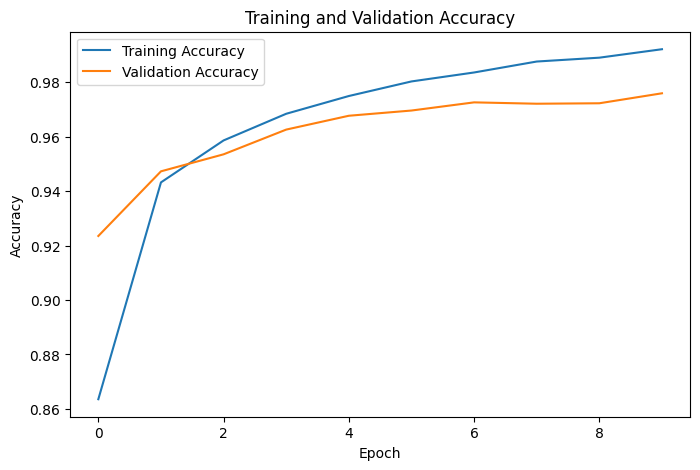

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

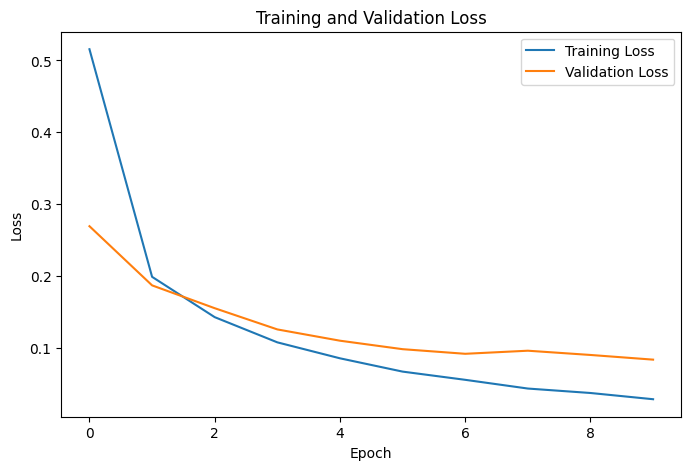

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Step 9 — Analyze the Learning Curves

**Questions:**

1. Does the model improve over time?
2. Is there a gap between training and validation performance?
3. Do you observe underfitting, overfitting, or a good balance?
4. At which epoch does the validation performance stop improving significantly?

> Justify your answer using the curves.

In [17]:
test_dataset = TensorDataset(X_test_t, y_test_labels)
test_loader = DataLoader(test_dataset, batch_size=250, shuffle=False)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.07385939313098788
Test accuracy: 0.9789


# Step 10 — Final Evaluation on the Test Set

The test set simulates unseen data.

**Questions:**

1. Why do we keep the test set separate until the end?
2. Compare training, validation, and test accuracy. Are they close?
3. What would it mean if test accuracy were much lower than validation accuracy?

In [18]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    y_pred_probs = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(y_pred_probs, axis=1)

print("Probability output shape:", y_pred_probs.shape)
print("Predicted labels shape:", y_pred.shape)

Probability output shape: (10000, 10)
Predicted labels shape: (10000,)


# Step 11 — Generate Predictions

The model outputs raw logits; we apply `softmax` manually (with `torch.no_grad()` since we don't need gradients here) to get probabilities for each class.  
We take the index of the highest probability as the predicted class.

**Questions:**

1. What is the shape of `y_pred_probs`?
2. Why do we use `argmax`?
3. What does a softmax output represent?
4. Why do we wrap this step in `torch.no_grad()` and call `model.eval()` first?

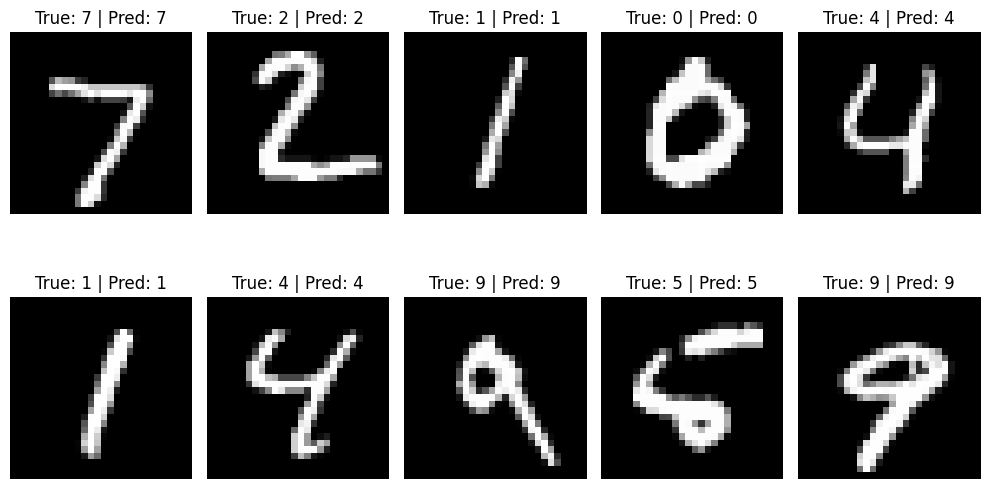

In [19]:
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"True: {y_test[i]} | Pred: {y_pred[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Visual Inspection of Predictions

**Questions:**

1. Are the predictions mostly correct?
2. For any wrong prediction, does the mistake seem understandable?
3. Why is it useful to inspect predictions visually?

In [20]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 969    0    2    1    1    0    2    1    4    0]
 [   0 1121    5    0    0    0    2    2    5    0]
 [   1    2 1018    2    1    0    2    4    2    0]
 [   0    0    6  993    0    1    0    5    4    1]
 [   0    0    4    1  960    0    3    3    1   10]
 [   2    0    0   11    1  868    3    0    6    1]
 [   5    3    1    1    4    2  940    0    2    0]
 [   0    1   12    3    0    1    0 1005    2    4]
 [   3    0    3    5    4    3    3    1  950    2]
 [   2    4    1    9    6    2    2    6   12  965]]


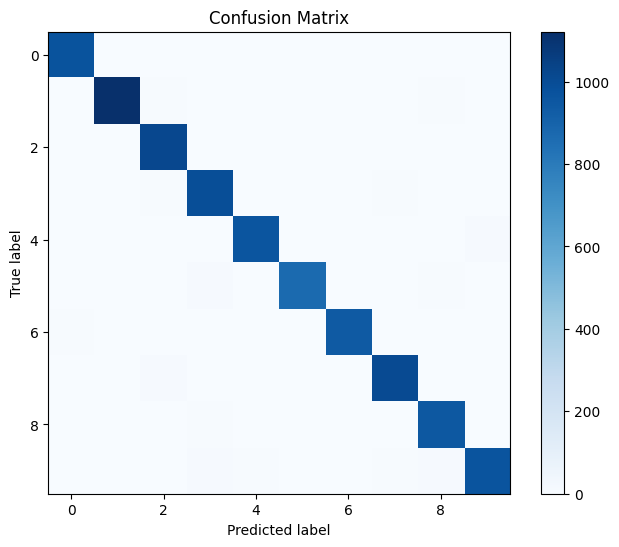

In [21]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
plt.show()

# Step 12 — Confusion Matrix

A confusion matrix helps us understand **which** classes are confused with each other.

**Questions:**

1. Which digits are classified most accurately?
2. Which pairs of digits are most often confused?
3. Why might these confusions happen?

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.96      0.98      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



# Precision, Recall, and F1-score

Accuracy is not the only useful metric.

**Questions:**

1. What is the difference between precision and recall?
2. Which class has the weakest F1-score?
3. Why is per-class analysis useful?

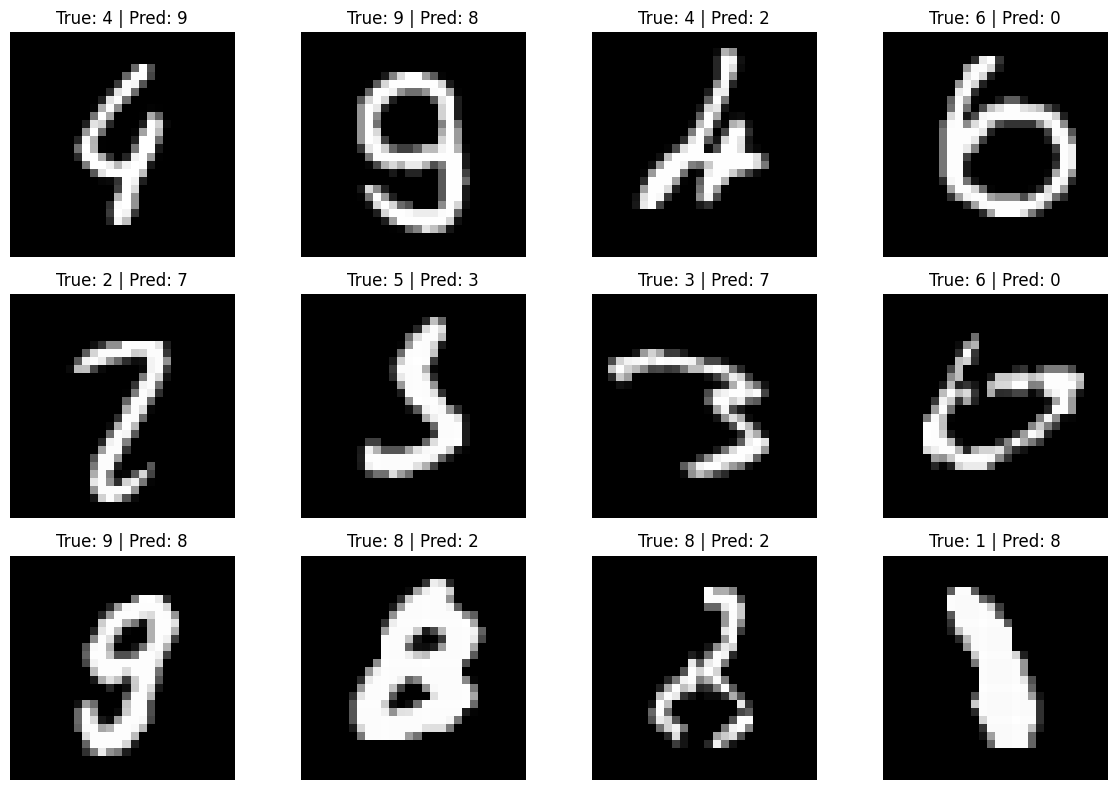

In [23]:
misclassified = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(misclassified[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Step 13 — Analyze the Model's Mistakes

This is one of the most useful parts of the lab.

**Questions:**

1. Are the mistakes understandable to a human?
2. Do some digits appear ambiguous or poorly written?
3. What do these mistakes tell us about the limitations of an MLP?

# Experiment 1 — Change the Architecture

Try a smaller and a larger model.

Examples:

- `128 -> 64`
- `256 -> 128`
- `512 -> 128`

For each model, record:

- training accuracy
- validation accuracy
- test accuracy

In [ ]:
class MLPExp(nn.Module):
    def __init__(self, input_dim=784, hidden1=128, hidden2=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model_exp = MLPExp(hidden1=128, hidden2=64).to(device)
criterion_exp = nn.CrossEntropyLoss()
optimizer_exp = optim.Adam(model_exp.parameters())

history_exp = train_model(model_exp, train_loader, val_loader, criterion_exp, optimizer_exp, device, epochs=10)

test_loss_exp, test_acc_exp = evaluate(model_exp, test_loader, criterion_exp, device)
print("Test accuracy:", test_acc_exp)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_exp["accuracy"], label="Training Accuracy")
plt.plot(history_exp["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

**Questions:**

1. Does a larger model always perform better?
2. Which model trains faster?
3. Which model generalizes best?

> Tip: re-run the cell above with `hidden1=256, hidden2=128` or `hidden1=512, hidden2=128` to compare, exactly like the TensorFlow version suggested.

# Experiment 2 — Change the Activation Function

Try:

- `relu`
- `sigmoid`
- `tanh`

Keep the rest of the architecture unchanged.

**Questions:**

1. Which activation converges faster?
2. Which activation gives the best validation accuracy?
3. Why is ReLU often preferred in deep learning?

In [ ]:
def build_mlp_with_activation(activation_name, hidden1=350, hidden2=50, input_dim=784, num_classes=10):
    activations = {
        "relu": nn.ReLU,
        "sigmoid": nn.Sigmoid,
        "tanh": nn.Tanh,
    }
    act_cls = activations[activation_name]
    return nn.Sequential(
        nn.Linear(input_dim, hidden1),
        act_cls(),
        nn.Linear(hidden1, hidden2),
        act_cls(),
        nn.Linear(hidden2, num_classes)
    )

results_activation = {}
for act_name in ["relu", "sigmoid", "tanh"]:
    print(f"\n--- Training with {act_name} activation ---")
    model_act = build_mlp_with_activation(act_name).to(device)
    criterion_act = nn.CrossEntropyLoss()
    optimizer_act = optim.Adam(model_act.parameters())
    hist_act = train_model(model_act, train_loader, val_loader, criterion_act, optimizer_act, device, epochs=10)
    results_activation[act_name] = hist_act

In [ ]:
plt.figure(figsize=(8, 5))
for act_name, hist_act in results_activation.items():
    plt.plot(hist_act["val_accuracy"], label=f"{act_name} (val)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy by Activation Function")
plt.legend()
plt.show()

# Experiment 3 — Change the Optimizer

Compare:

- Adam
- SGD
- RMSprop

**Questions:**

1. Which optimizer seems the most stable?
2. Which one reaches a good result faster?
3. Do the final results differ a lot?

In [ ]:
def build_optimizer(name, params):
    if name == "adam":
        return optim.Adam(params)
    elif name == "sgd":
        return optim.SGD(params, lr=0.01)
    elif name == "rmsprop":
        return optim.RMSprop(params)
    else:
        raise ValueError(f"Unknown optimizer: {name}")

results_optimizer = {}
for opt_name in ["adam", "sgd", "rmsprop"]:
    print(f"\n--- Training with {opt_name} optimizer ---")
    model_opt = MLP().to(device)
    criterion_opt = nn.CrossEntropyLoss()
    optimizer_opt = build_optimizer(opt_name, model_opt.parameters())
    hist_opt = train_model(model_opt, train_loader, val_loader, criterion_opt, optimizer_opt, device, epochs=10)
    results_optimizer[opt_name] = hist_opt

In [ ]:
plt.figure(figsize=(8, 5))
for opt_name, hist_opt in results_optimizer.items():
    plt.plot(hist_opt["val_accuracy"], label=f"{opt_name} (val)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy by Optimizer")
plt.legend()
plt.show()

# Optional Extension — Add Dropout

Dropout can reduce overfitting by randomly deactivating neurons during training.

> In PyTorch, `nn.Dropout` behaves differently in training vs. evaluation mode: it only randomly zeroes activations when the model is in `.train()` mode (which our `train_model`/`evaluate` helpers already set correctly), and is disabled automatically during `.eval()`.

In [ ]:
class MLPDropout(nn.Module):
    def __init__(self, input_dim=784, hidden1=350, hidden2=50, num_classes=10, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model_dropout = MLPDropout(p=0.3).to(device)
criterion_dropout = nn.CrossEntropyLoss()
optimizer_dropout = optim.Adam(model_dropout.parameters())

history_dropout = train_model(model_dropout, train_loader, val_loader, criterion_dropout, optimizer_dropout, device, epochs=10)

**Questions:**

1. Does dropout improve validation performance?
2. Does it reduce overfitting?
3. What trade-off do you observe?

# Optional Extension — Early Stopping

Early stopping stops training when validation performance no longer improves.

> PyTorch has no built-in `EarlyStopping` callback like Keras. We implement the same logic manually: track the best validation loss seen so far, save (in memory) the best model weights with `copy.deepcopy(model.state_dict())`, and stop once `patience` epochs pass without improvement.

In [ ]:
import copy

def train_model_early_stopping(model, train_loader, val_loader, criterion, optimizer, device,
                                 epochs=20, patience=3):
    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)  # restore_best_weights=True equivalent

    return history


model_es = MLP().to(device)
criterion_es = nn.CrossEntropyLoss()
optimizer_es = optim.Adam(model_es.parameters())

history_es = train_model_early_stopping(model_es, train_loader, val_loader, criterion_es, optimizer_es,
                                         device, epochs=20, patience=3)

**Questions:**

1. Why is early stopping useful?
2. Did the training stop before 20 epochs?
3. Why can this improve generalization?

# Final Questions

Answer the following in complete sentences:

1. What is the role of each major step in this notebook?
   - data loading
   - preprocessing
   - model construction
   - training
   - evaluation

2. Why do we flatten images for an MLP?

3. Why is an MLP not the ideal architecture for image tasks compared with a CNN?

4. Based on your curves, did your baseline model underfit, overfit, or perform well?

5. Which digits were hardest to classify, and why?

6. What modification improved your model the most?

7. If you had more time, what would you try next?

8. What are the main practical differences you noticed between the TensorFlow/Keras workflow and the PyTorch workflow (e.g. explicit training loop, label encoding, model modes)?